In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


In [8]:
titanic_df=pd.read_csv('train.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
features = ['Pclass','Sex','Age','SibSp','Parch']
x=titanic_df[features]# Independent variable
y=titanic_df['Survived']# Target or dependent variable
x['Sex']=x['Sex'].map({'male':0,'female':1})
x.head() 

C:\Users\jeeva\AppData\Local\Temp\ipykernel_11204\2747640882.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Sex']=x['Sex'].map({'male':0,'female':1})


,Pclass,Sex,Age,SibSp,Parch
0,3,0,22.0,1,0
1,1,1,38.0,1,0
2,3,1,26.0,0,0
3,1,1,35.0,1,0
4,3,0,35.0,0,0


In [10]:
x.isnull().sum()

Pclass      0
Sex         0
Age       177
SibSp       0
Parch       0
dtype: int64

In [11]:
x['Age'].fillna(x['Age'].median(),inplace=True) 

C:\Users\jeeva\AppData\Local\Temp\ipykernel_11204\2501433929.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['Age'].fillna(x['Age'].median(),inplace=True)
C:\Users\jeeva\AppData\Local\Temp\ipykernel_11204\2501433929.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Age'].fillna(x['Age'].median(),inplace=True)


In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
dtmodel=DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=42)
dtmodel.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [13]:
y_pred=dtmodel.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy}') 

Accuracy: 0.8044692737430168


In [14]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



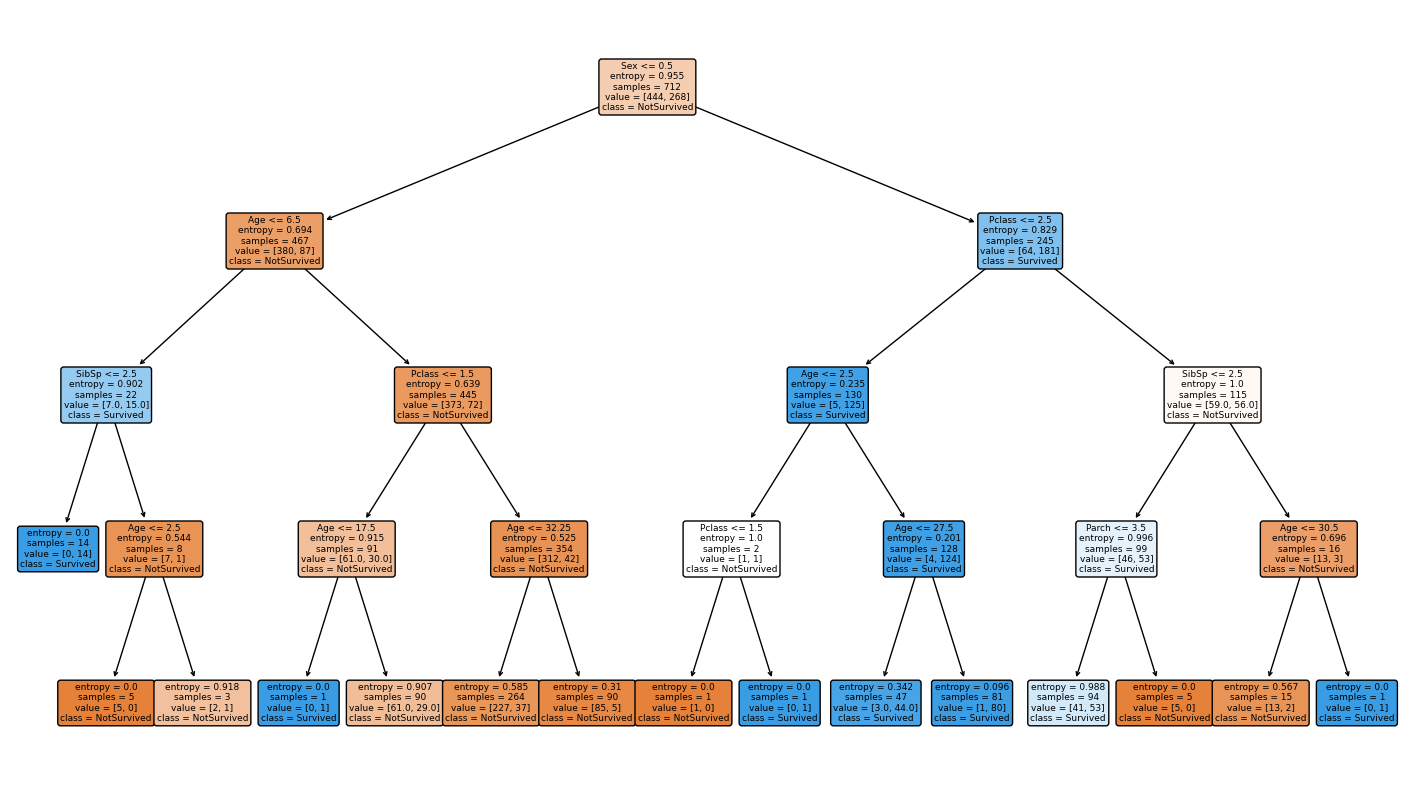

In [16]:
plt.figure(figsize=(18,10))
plot_tree(dtmodel,filled=True,feature_names=features,class_names=['NotSurvived','Survived'],rounded=True)
plt.show()